In [21]:
#TASK1:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv('customer_churn_nn.csv')

# Displaying the first few rows
display(df.head())

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [20]:
rows, cols = df.shape
print(f"Number of Rows: {rows}")
print(f"Number of Columns: {cols}")

Number of Rows: 2000
Number of Columns: 17


In [3]:
print("Data Types of Features:")
print(df.dtypes)

Data Types of Features:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [4]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [5]:
display(df.describe().T) #Transposed

,count,mean,std,min,25%,50%,75%,max
tenure_months,2000.0,25.362000,14.128651,1.00,15.0000,23.000,33.0000,72.00
monthly_charges_inr,2000.0,766.487295,393.420070,255.45,427.7825,688.355,1007.3725,2156.52
avg_login_days_per_month,2000.0,18.099000,5.400628,0.00,15.0000,18.000,22.0000,30.00
support_tickets_last_90_days,2000.0,1.953000,1.463852,0.00,1.0000,2.000,3.0000,8.00
payment_delay_days,2000.0,3.555000,3.885682,0.00,1.0000,2.000,5.0000,31.00
data_usage_gb,2000.0,90.007625,53.215719,0.50,51.7775,80.245,119.0975,265.51
satisfaction_score,2000.0,6.873950,1.524280,1.00,5.8750,6.800,8.0000,10.00
last_complaint_days_ago,2000.0,46.616500,55.065775,0.00,6.0000,28.500,68.0000,424.00
discount_percent,2000.0,8.255000,7.553708,0.00,0.0000,5.000,15.0000,20.00
autopay_enabled,2000.0,0.597500,0.490524,0.00,0.0000,1.000,1.0000,1.00


Distribution of Target Variable ('churn'):
churn
0    1969
1      31
Name: count, dtype: int64

Churn Rate: 1.55%


/tmp/ipykernel_16434/2846052048.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churn', palette='viridis')


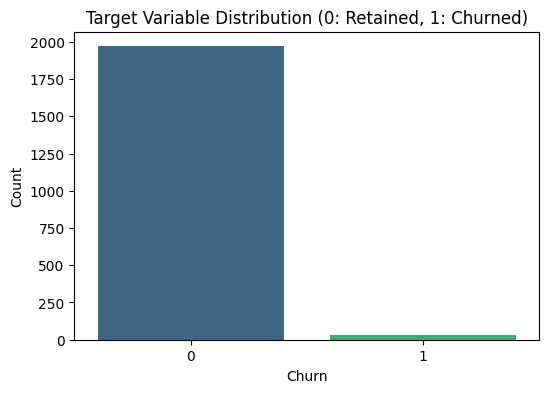

In [6]:
# Counting the distributions
churn_counts = df['churn'].value_counts()
print("Distribution of Target Variable ('churn'):")
print(churn_counts)
print(f"\nChurn Rate: {(churn_counts[1] / rows) * 100:.2f}%")

# Visualizing the distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn', palette='viridis')
plt.title('Target Variable Distribution (0: Retained, 1: Churned)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [7]:
#TASK2:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

# 1. Dropping the identifier column
df = df.drop('customer_id', axis=1)

# 2. Separating features (X) and target (y)
X = df.drop('churn', axis=1)
y = df['churn']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (2000, 15)
Target (y) shape: (2000,)


In [8]:
# Splitting the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Maintains the ~1.5% churn rate in both splits
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 1600 samples
Testing set size: 400 samples


In [9]:
# Identifying categorical and numerical columns
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Creating a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# Fitting on the training data ONLY, then transform both train and test sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Extracting feature names to see what our new columns look like
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_feature_names)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after One-Hot Encoding: {X_train_processed.shape[1]}")
print("\nFirst row of processed training data:")
print(np.round(X_train_processed[0], 2))

Original number of features: 15
Number of features after One-Hot Encoding: 24

First row of processed training data:
[-0.04 -0.39  0.91  1.41 -0.65  0.42 -0.65  0.4   1.55 -1.21  1.99  0.
  1.    0.    0.    0.    0.    1.    1.    0.    1.    0.    0.    0.  ]


In [10]:
#TASK3:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

tf.keras.backend.clear_session()

# Defining the model architecture
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_processed.shape[1],)),

    # Dropout layer to randomly turn off 20% of neurons to prevent overfitting
    Dropout(0.2),

    # Second Hidden Layer
    # 16 neurons with ReLU activation
    Dense(16, activation='relu'),

    # Output Layer
    # A single neuron because this is binary classification (0 or 1).
    # The 'sigmoid' activation function squashes the output into a probability between 0 and 1.
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compiling the model
model.compile(
    optimizer='adam',              # Adaptive Moment Estimation: automatically adjusts learning rate
    loss='binary_crossentropy',    # Standard loss function for binary classification
    metrics=[
        'accuracy',
        # Adding Recall as a metric because we saw in Task 1 that the dataset is highly imbalanced
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Display a summary of the model's architecture and parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#TASK 4:


# Training the model
history = model.fit(
    X_train_processed,
    y_train,
    epochs=20,               # Number of times to go through the dataset
    batch_size=32,           # Number of samples per gradient update
    validation_split=0.2,    # Use 20% of the training data for validation during training
    verbose=1                # Show a progress bar
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7867 - loss: 0.4963 - recall: 0.2174 - val_accuracy: 0.9906 - val_loss: 0.2559 - val_recall: 0.0000e+00
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9805 - loss: 0.2130 - recall: 0.0000e+00 - val_accuracy: 0.9937 - val_loss: 0.1122 - val_recall: 0.0000e+00
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.1395 - recall: 0.0000e+00 - val_accuracy: 0.9937 - val_loss: 0.0694 - val_recall: 0.0000e+00
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.1157 - recall: 0.0000e+00 - val_accuracy: 0.9937 - val_loss: 0.0552 - val_recall: 0.0000e+00
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.0984 - recall: 0.0000e+00 - val_accuracy: 0.9937 - val_loss: 0.0491 - val_recall: 0.0000e+00
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0983 - recall: 0.0000e+00 - val_accuracy: 0.9937 - val_loss: 0.0

In [13]:
# Evaluating on training data
train_loss, train_acc, train_recall = model.evaluate(X_train_processed, y_train, verbose=0)
print(f"Training Accuracy: {train_acc:.4f} | Training Loss: {train_loss:.4f}")

# Evaluating on testing data
test_loss, test_acc, test_recall = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"Testing Accuracy:  {test_acc:.4f} | Testing Loss:  {test_loss:.4f}")

Training Accuracy: 0.9850 | Training Loss: 0.0565
Testing Accuracy:  0.9850 | Testing Loss:  0.0626


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



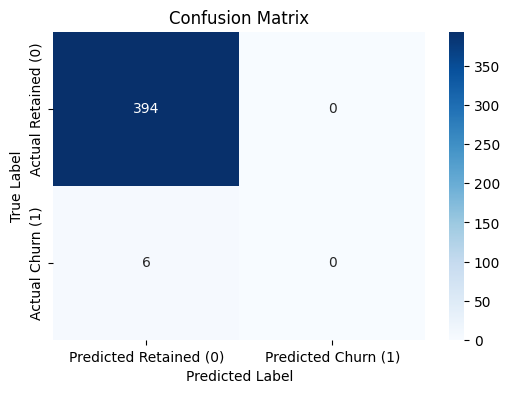

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Making predictions (outputs probabilities between 0 and 1)
y_pred_prob = model.predict(X_test_processed)

# 2. Converting probabilities to binary predictions (threshold = 0.5)
y_pred = (y_pred_prob > 0.5).astype(int)

# 3. Generating Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))

# 4. Generating and plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Retained (0)', 'Predicted Churn (1)'],
            yticklabels=['Actual Retained (0)', 'Actual Churn (1)'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [16]:
#TASK 5:

import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report

def run_experiment(name, layers, activation, optimizer, batch_size, epochs):
    """
    Builds, trains, and evaluates a neural network with given hyperparameters.
    """
    # Clear session and set seed for reproducibility
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    # 1. Build Model dynamically
    model = Sequential()
    model.add(tf.keras.Input(shape=(X_train_processed.shape[1],)))

    for units in layers:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(0.2)) # Standard dropout to prevent overfitting

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # 2. Compile
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # 3. Train
    model.fit(X_train_processed, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    # 4. Evaluate
    test_loss, test_acc = model.evaluate(X_test_processed, y_test, verbose=0)
    y_pred = (model.predict(X_test_processed, verbose=0) > 0.5).astype(int)

    # 5. Extract Recall for Class 1 (Churn)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    churn_recall = report['1']['recall']

    # Return dictionary of results
    return {
        'Experiment': name,
        'Layers (Neurons)': str(layers),
        'Activation': activation,
        'Batch Size': batch_size,
        'Epochs': epochs,
        'Optimizer': optimizer,
        'Test Accuracy': round(test_acc, 4),
        'Churn Recall': round(churn_recall, 4)
    }

In [17]:
results = []

# Experiment 1: The Baseline (from Task 3/4)
results.append(run_experiment(
    name='Exp 1: Baseline',
    layers=[32, 16], activation='relu', optimizer='adam', batch_size=32, epochs=20
))

# Experiment 2: Wider & Deeper Network (More capacity to learn complex patterns)
results.append(run_experiment(
    name='Exp 2: Wider & Deeper',
    layers=[128, 64, 32], activation='relu', optimizer='adam', batch_size=32, epochs=20
))

# Experiment 3: Different Activation and Larger Batch Size
results.append(run_experiment(
    name='Exp 3: Tanh & Large Batch',
    layers=[32, 16], activation='tanh', optimizer='adam', batch_size=128, epochs=50
))

# Experiment 4: Standard Gradient Descent (SGD) instead of Adam
results.append(run_experiment(
    name='Exp 4: SGD Optimizer',
    layers=[32, 16], activation='relu', optimizer='sgd', batch_size=32, epochs=50
))

# Create a DataFrame to display the comparison table
results_df = pd.DataFrame(results)
display(results_df)

,Experiment,Layers (Neurons),Activation,Batch Size,Epochs,Optimizer,Test Accuracy,Churn Recall
0,Exp 1: Baseline,"[32, 16]",relu,32,20,adam,0.9850,0.0000
1,Exp 2: Wider & Deeper,"[128, 64, 32]",relu,32,20,adam,0.9875,0.1667
2,Exp 3: Tanh & Large Batch,"[32, 16]",tanh,128,50,adam,0.9850,0.0000
3,Exp 4: SGD Optimizer,"[32, 16]",relu,32,50,sgd,0.9850,0.0000


In [18]:
!pip freeze > requirements.txt